# Cylinder 2D with Synthetic Jets

A cylinder in a stream at $Re = 100$ sheds vortices, alternately from the top and from the bottom, and that shedding is where most of its drag comes from. Two slots in the cylinder surface, at the top and at the bottom, blow and suck in antiphase, adding no net mass to the flow; used at the right moments they break the shedding cycle. The force on the cylinder is reported as two dimensionless coefficients:

| | direction | uncontrolled, published mesh |
|---|---|---|
| drag, $C_d$ | along the stream | around $1.4$, always positive |
| lift, $C_l$ | across the stream | swings between $\pm 0.27$ once per shedding period |

The observation is the pressure $p_i$ at 99 probes on an 11 by 9 grid in the wake. Every $0.4$ time units the policy turns it into the action $a$, the jet velocity, bounded to $[-1, 1]$ against a free stream of $1$. The reward is $C_{d,0} - (C_d + 0.2\,|C_l|)$ averaged over one shedding period, so doing nothing scores about zero and suppressing the shedding scores above it.

In [1]:
%%capture
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sys.path.insert(0, str(Path.cwd().parent / "src"))

import uqtopus as uqt
import uqtopus.rl as rl
from uqtopus.rl.algos import PPO

case = Path("templates/cylinder2D_jets")
root = Path("experiments/cylinder2D_jets")

have_controller = any(
    (Path(os.environ[key]) / "libuqtopusPolicy.so").exists()
    for key in ("FOAM_USER_LIBBIN", "FOAM_LIBBIN")
    if os.environ.get(key)
)

## 1. A cheaper version of the published case

The published case costs about 5 core hours per episode and 6200 for the training. The cost is cells times time steps, so both were cut:

| | published | here |
|---|---|---|
| cells per direction | `meshDensity 1.0` | `meshDensity 0.5` |
| wake length | 25D | 12D |
| far field | 9D above and below | 6D |
| **total cells** | **7180** | **1580** |
| **decisions per episode** | **400** | **100** |

That is about eighteen times less work per episode. The 99 probes are unchanged, since their grid ends at 8D. Near 8D the cells are 0.89 wide against a probe spacing of 0.745, so the last probe columns carry less independent information than on the published mesh. The coarser mesh shifts $C_d$ by a few percent, which is why section 5 measures the baseline on it.

## 2. Policy spec

The spec of notebook 06, with the 99 pressure probes as observation and the jet patch as target. `ramp_fraction = 0.5` is the published ramp: the jet moves to each new value over 0.2 of the 0.4 interval.

In [3]:
CFD_STEP = 0.01
EPISODE_END = 40.0

x_probe = np.linspace(0.55, 8.0, 11)
y_probe = np.linspace(-1.25, 1.25, 9)
probes = np.array([(x, y, 0.0) for x in x_probe for y in y_probe])

spec = rl.PolicySpec(
    observation=rl.ObservationSpec(
        sources=(rl.ProbeSource(field_name="p", positions=probes, name="wake"),)
    ),
    action=rl.ActionSpec(
        name="jet",
        targets="jet",
        low=-1.0,
        high=1.0,
        distribution="gaussian",
        ramp_fraction=0.5,
    ),
    control_interval=0.4,
)

n_control = int(EPISODE_END / spec.control_interval)
spec

PolicySpec(obs_dim=99, act_dim=1, dist='gaussian', dt=0.4, hash=38e67b87cbfc7a07)

## 3. How the policy gets into OpenFOAM

Python and the solver exchange two files:

| file | direction | content |
|---|---|---|
| `policy.onnx` | Python to solver | the network, frozen, with the spec in its metadata |
| `postProcessing/uqtopusPolicy/<t>/trajectory.dat` | solver to Python | one row per decision: time, the 99 observations, the action |

The solver evaluates the graph with ONNX Runtime inside `uqtopusBoundaryCondition`, a boundary condition compiled into `libuqtopusPolicy.so` (section 8) and loaded by the `libs` entry of `controlDict`. Retraining only replaces the `.onnx` file.

### The templated file

Only `system/controlDict` carries a placeholder, where the contract sits beside the `libs` line. The jet patch of `0.orig/U` is fixed text: its type, the jet direction and the value before the first decision.

In [4]:
text = (case / "0.orig" / "U").read_text()
print(text[text.index("    jet"):text.index("    inlet")])

    jet
    {
        type            uqtopusBoundaryCondition;
        direction       (0 1 0);
        value           uniform (0 0 0);
    }



`controller_params` renders the contract for the key `system__controlDict__controller`: folder `system`, file `controlDict`, variable `controller`. The block carries the policy path, the schedule, the bounds and the 99 probe positions. `specHash` identifies the spec, and the reader refuses a trajectory written under another one.

In [5]:
params = rl.controller_params(
    spec, root.resolve() / "policy.onnx", "system__controlDict__controller", seed=0
)

block = params["system__controlDict__controller"].splitlines()
print("\n".join(block[:9]))
print(f"\n    ... {len(block) - 20} lines omitted, the 99 probe positions among them ... \n")
print("\n".join(block[-11:]))

uqtopusPolicy
{
    type            uqtopusPolicy;
    policy          "/home/gbm/projects/UQTOPUS/examples/experiments/cylinder2D_jets/policy.onnx";
    specHash        "38e67b87cbfc7a07";
    controlInterval 0.4;
    startTime       0;
    seed            0;
    observation

    ... 120 lines omitted, the 99 probe positions among them ... 

        low             (-1);
        high            (1);
        targets
        (
            {
                name            jet;
                component       0;
            }
        );
    }
}


## 4. The reward

`forceCoeffs` writes $C_d$ and $C_l$ every CFD step, and the trajectory has one row per decision. `align_to_control` averages the forces over each control interval and `moving_average` over one shedding period, so the reward follows the action rather than the phase of the oscillation. `CD_BASELINE` only sets where zero reward sits; the value below comes from the published mesh, and section 5 replaces it with the one of this mesh.

The map is the reward for each pair of coefficients; the black line is zero reward.

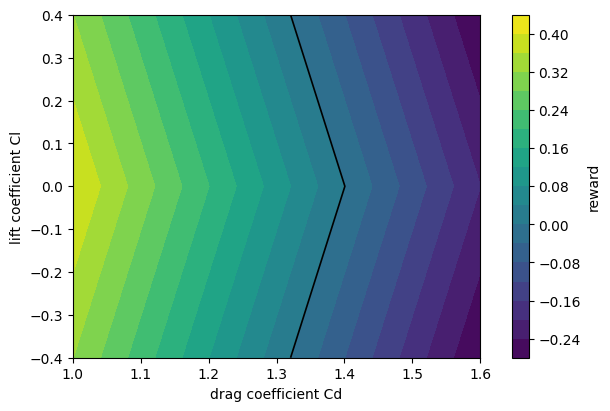

In [6]:
SHEDDING_PERIOD = 5.8
LIFT_WEIGHT = 0.2
CD_BASELINE = 1.4007

window = int(round(SHEDDING_PERIOD / spec.control_interval))

def reward(ds):
    """Drag reduction against the uncontrolled baseline, penalized by lift."""
    cd = rl.moving_average(ds["Cd"], window)
    cl = rl.moving_average(np.abs(ds["Cl"]), window)
    return CD_BASELINE - (cd + LIFT_WEIGHT * cl)


Cd, Cl = np.meshgrid(np.linspace(1.0, 1.6, 121), np.linspace(-0.4, 0.4, 161))
r = CD_BASELINE - (Cd + LIFT_WEIGHT * np.abs(Cl))

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
image = ax.contourf(Cd, Cl, r, levels=20)
ax.contour(Cd, Cl, r, levels=[0.0], colors="k", linewidths=1.2)
ax.set_xlabel("drag coefficient Cd")
ax.set_ylabel("lift coefficient Cl")
fig.colorbar(image, ax=ax, label="reward")
plt.show()

On a synthetic force history, standing in for a policy that starts suppressing the shedding at $t = 10$. No simulation is involved here.

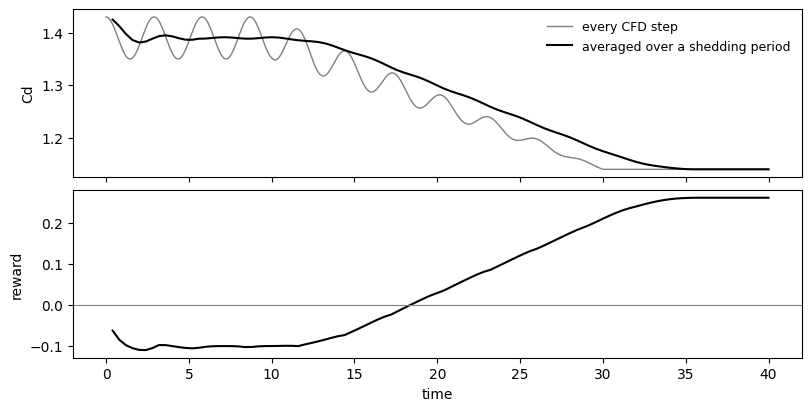

return over the episode: 5.6


In [7]:
t_cfd = np.arange(0.0, EPISODE_END + CFD_STEP, CFD_STEP)
rate = 2 * np.pi / SHEDDING_PERIOD
suppressed = np.clip((t_cfd - 10.0) / 20.0, 0.0, 1.0)

forces = xr.Dataset(
    {
        "Cd": ("time", 1.39 - 0.25 * suppressed
               + 0.04 * (1 - suppressed) * np.cos(2 * rate * t_cfd)),
        "Cl": ("time", 0.9 * (1 - suppressed) * np.sin(rate * t_cfd)),
    },
    coords={"time": t_cfd},
)

control_times = np.arange(1, n_control + 1) * spec.control_interval
aligned = rl.align_to_control(forces, control_times, how="mean")
rewards = reward(aligned)

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True, constrained_layout=True)
axes[0].plot(forces["time"], forces["Cd"], color="tab:gray", lw=1,
             label="every CFD step")
axes[0].plot(aligned["time"], rl.moving_average(aligned["Cd"], window), color="k",
             lw=1.5, label="averaged over a shedding period")
axes[0].set_ylabel("Cd")
axes[0].legend(frameon=False, fontsize=9)
axes[1].plot(control_times, rewards, color="k", lw=1.5)
axes[1].axhline(0.0, color="gray", lw=0.8)
axes[1].set_ylabel("reward")
axes[1].set_xlabel("time")
plt.show()

print(f"return over the episode: {rewards.sum():.1f}")

## 5. The uncontrolled baseline

`./Allwarmup` runs the case without control until the shedding saturates, writes that state into `0.orig` so every episode starts from it, and keeps its force history. The mean drag of that history over whole shedding periods is `CD_BASELINE`. Delete `warmup/` once the number is recorded, since the template is copied into every episode directory.

In [8]:
warmup = case / "warmup"

if (warmup / "postProcessing" / "forces").is_dir():
    history = rl.read_function_object(warmup, "forces")
    settled = history.sel(time=slice(100.0, None))
    periods = int((float(settled["time"][-1]) - float(settled["time"][0]))
                  / SHEDDING_PERIOD)
    settled = settled.sel(
        time=slice(None, float(settled["time"][0]) + periods * SHEDDING_PERIOD)
    )
    CD_BASELINE = float(settled["Cd"].mean())
    print(f"Cd over {periods} shedding periods: {CD_BASELINE:.4f}, "
          f"against 1.4007 measured on the reference mesh")
else:
    print(f"no baseline yet: run ./Allwarmup in {case}")

no baseline yet: run ./Allwarmup in templates/cylinder2D_jets


## 6. One episode

As in notebook 06, one solver run is one episode; here the runner also reads the `forces` function object for the reward.

In [9]:
simulator = uqt.OpenFOAMSimulator(
    template_path=case,
    solver_script="Allrun",
    output_path=root,
    qoi_variables=["U", "p"],
)

runner = rl.ClosedLoopRunner(
    simulator,
    spec,
    reward,
    controller_keys="system__controlDict__controller",
    function_objects=["forces"],
)
runner

ClosedLoopRunner(obs_dim=99, act_dim=1, spec_hash=38e67b87cbfc7a07)

100 control steps, return -30.47


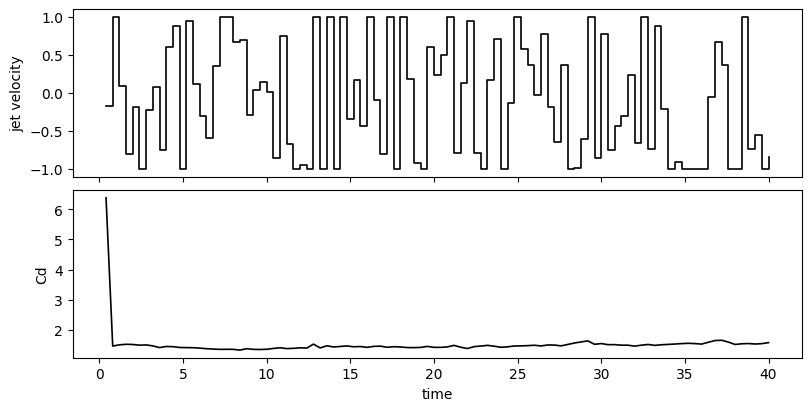

In [10]:
def plot_episode(ds):
    fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True,
                             constrained_layout=True)
    axes[0].plot(ds["time"], np.clip(ds["action"].isel(act_component=0), -1, 1),
                 drawstyle="steps-post", color="k", lw=1.2)
    axes[0].set_ylabel("jet velocity")
    axes[1].plot(ds["time"], ds["Cd"], color="k", lw=1.2)
    axes[1].set_ylabel("Cd")
    axes[1].set_xlabel("time")
    plt.show()


if have_controller:
    untrained = rl.export_random_policy(spec, root / "policy_untrained.onnx", seed=0)
    rollout = runner.collect(untrained, n_episodes=1)
    episode = rollout.episodes[0]
    print(f"{episode.sizes['time']} control steps, "
          f"return {float(episode['reward'].sum()):.2f}")
    plot_episode(episode)

## 7. Training

The hyperparameters are the published ones: two hidden layers of 64, learning rate $5 \times 10^{-4}$, 12 gradient epochs per update, clip $0.2$, discount $0.99$. Each iteration runs `EPISODES_PER_ITERATION` cases at once.

In [11]:
ITERATIONS = 100
EPISODES_PER_ITERATION = 6

model = PPO(
    "MlpPolicy",
    runner,
    n_episodes=EPISODES_PER_ITERATION,
    n_jobs=EPISODES_PER_ITERATION,
    export_dir=root / "policies",
    policy_kwargs={"net_arch": [64, 64]},
    learning_rate=5e-4,
    batch_size=n_control,
    n_epochs=12,
    clip_range=0.2,
    gamma=0.99,
    verbose=1,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
def plot_returns(returns):
    fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
    ax.plot(returns, color="k", lw=1.2)
    ax.axhline(0.0, color="gray", lw=0.8)
    ax.set_xlabel("iteration")
    ax.set_ylabel("mean return")
    plt.show()


if have_controller:
    model.learn(total_timesteps=ITERATIONS * EPISODES_PER_ITERATION * n_control)
    plot_returns(model.returns_history)

## 8. Building the solver

The controlled episodes need `libuqtopusPolicy.so`. Once per machine:

```bash
uqtopus rl-build --install-onnxruntime
```

It finds OpenFOAM and the ONNX Runtime, downloads the runtime when none is found, and writes the library into `$FOAM_USER_LIBBIN`, where the solver finds it through the `libs ("libuqtopusPolicy.so");` line of `system/controlDict`. Once it exists, `have_controller` in the imports cell is true.